In [1]:
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from typing import TypedDict,List
from langgraph.graph import StateGraph,START,END,add_messages
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser,PydanticOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pydantic import BaseModel,Field
from langchain_community.vectorstores import FAISS
from langchain_community.tools.tavily_search import TavilySearchResults

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
loader1 = PyPDFLoader("documents/book1.pdf")
loader2 = PyPDFLoader("documents/book2.pdf")
loader3 = PyPDFLoader("documents/book3.pdf")

In [3]:
docs = loader1.load() + loader2.load() + loader3.load()
len(docs)

2123

In [4]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap = 200
)

chunk = splitter.split_documents(docs)

len(chunk)

5918

In [5]:
load_dotenv()

model = ChatOpenAI()
model1 = ChatOpenAI()

In [6]:
embedding = OpenAIEmbeddings()

parser = StrOutputParser()

vector_store = FAISS.from_documents(
        embedding=embedding,
        documents=chunk
)

In [7]:
retriever = vector_store.as_retriever(
    search_type = 'mmr',
    serach_kwargs = {'k':4}
)

In [102]:
class RagState(TypedDict,total=False):

    question : str
    documents : List[Document]

    good_docs : List[Document]
    verdict : str
    reason : str

    strip : List[str]
    kept_strip : List[str]
    refined_content : str

    web_docs : List[Document]

    web_query : str

    answer : str

In [103]:
class KeepOrDrop(BaseModel):

    keep : bool = Field(description='True or False')

parser1 = PydanticOutputParser(pydantic_object=KeepOrDrop)

In [104]:
def retrieve(state:RagState)->dict:

    question = state['question']

    response = retriever.invoke(question)

    print('Documents retrieved length of docs is : ',len(response))

    return {'documents':response}

In [105]:
import re

def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [106]:
def refine(state:RagState)->dict:

    #refined_content = state.get('refined_content',"")

    question = state['question']

    #documents = state['documents']
    good_docs = state['good_docs']
    web_docs = state.get('web_docs','')
    verdict = state['verdict']

    if verdict == 'CORRECT':
        context = '\n'.join(f"- {docs.page_content}" for docs in good_docs)
    else:
        context = '\n'.join(f"- {docs.page_content}" for docs in web_docs)

    strips = decompose_to_sentences(context)

    template = ChatPromptTemplate([
        ('system',
         "You are a strict relevance filter.\n"
        "Return keep=true only if the sentence directly helps answer the question.\n"
        "Use ONLY the sentence. Output JSON only. \n"),
        ('user',"Question: {question}\n\nSentence:\n{sentence}")
    ],
    input_variables = ['question','sentence'],
    )

    kept : List[str] =[]

    model_with_structured_output = model.with_structured_output(KeepOrDrop)
    chain = template | model_with_structured_output 
    for s in strips:
        keep_drop : KeepOrDrop = chain.invoke({'question':question,'sentence':s})
        #keep_drop_dict = keep_drop.model_dump()
        if keep_drop.keep:
            kept.append(s)

    refined_content = ''.join(kept).strip()

    print('Refined content generated : ',refined_content)

    return {
        'strips':strips,
        'keep_strip':kept,
        'refined_content':refined_content
    }

In [107]:
def generate(state:RagState)->dict:

    question = state['question']
    refined_content = state['refined_content']
    
    template = ChatPromptTemplate([
        ('system',"You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'"),
        ('user',"Question: {question}\n\nRefined context:\n{refined_content}")
    ],
    input_variables = ['question','refined_context']
    )

    chain = template | model | parser

    response = chain.invoke({'question':question,'refined_content':refined_content})

    print('output generated : ',response)

    return {'answer':response}

In [108]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [109]:
class DocEvalScore(BaseModel):

    score : float
    reason : str

#parser2 = PydanticOutputParser(pydantic_object=DocEvalScore)

template = ChatPromptTemplate([
    ('system',"You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only. \n"),
    ('human',"Question: {question}\n\nChunk:\n{chunk}")
],
input_variables = ['question','chunk'], 
)

model_with_structured_output = model.with_structured_output(DocEvalScore)

chain = template | model_with_structured_output 

def eval_each_node(state:RagState)->dict:

    question = state['question']
    documents = state['documents']

    score : List[float] = []
    reason : List[str] = []
    good_docs : List[Document] = []

    for doc in documents:
        doc_eval_score : DocEvalScore = chain.invoke({'question':question,'chunk':doc.page_content})
        #doc_eval_score_dict = doc_eval_score.model_dump()
        score.append(doc_eval_score.score)
        reason.append(doc_eval_score.reason)

        if doc_eval_score.score > LOWER_TH:
            good_docs.append(doc)

    if any(s > UPPER_TH for s in score):
        print('Correct :')
        return {
            'good_docs':good_docs,
            'verdict':'CORRECT',
            'reason': f"At least one doc score is greater that {UPPER_TH}"
        }
    
    if len(score)>0 and all(s<LOWER_TH for s in score):
        print('Incorrect : ')
        return {
            'good_docs':[],
            'verdict':'INCORRECT',
            'reason': f"All doc score is less than {LOWER_TH}"
        }
    
    print('Ambiguous : ')
    return {
        'good_docs':good_docs,
        'verdict':'AMBIGUOUS',
        'reason': f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}"
    }

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_openai\chat_models\base.py:2181: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [110]:
def conditional_edge(state : RagState)->dict:
    verdict = state['verdict']

    if verdict == 'CORRECT':
        return "refine"
    elif verdict == 'INCORRECT':
        return "query_rewrite"
    else:
        return "ambiguous"

def ambiguous(state:RagState)->dict:
    reason = state['reason']
    return {'answer':f"Ambiguous {reason}"}

In [111]:
tavily = TavilySearchResults(max_results=5)

def web_search(state:RagState)->dict:
    
    web_query = state.get('web_query')
    print(web_query)

    results = tavily.invoke({'query':web_query})

    web_docs = []
    for r in results or []:

        title = r.get('title','')
        url = r.get('url','')
        content = r.get('content','')

        text = f"TITLE : {title}\n\nURL: {url} \nCONTENT: {content}"

        web_docs.append(Document(page_content=text,metadata={'url':url,'title':title}))

    print("Control is at web search : ",[doc.page_content for doc in web_docs])

    return {'web_docs':web_docs}

In [112]:
class WebQuery(BaseModel):

    query : str

template = ChatPromptTemplate([
        ("system",
                "Rewrite the user question into a web search query composed of keywords.\n"
                "Rules:\n"
                "- Keep it short (6–14 words).\n"
                "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
                "- Do NOT answer the question.\n"
                "- Return JSON with a single key: query"),
        ('human',"Question: {question}")
        ],
        input_variables = ['question']
        )

model_with_structure = model.with_structured_output(WebQuery)

def query_rewrite(state:RagState)->dict:

    question = state['question']

    chain = template | model_with_structure

    response = chain.invoke({'question':question})

    print("Control is at query_rewrite : ",response.query)

    return {'web_query':response.query}

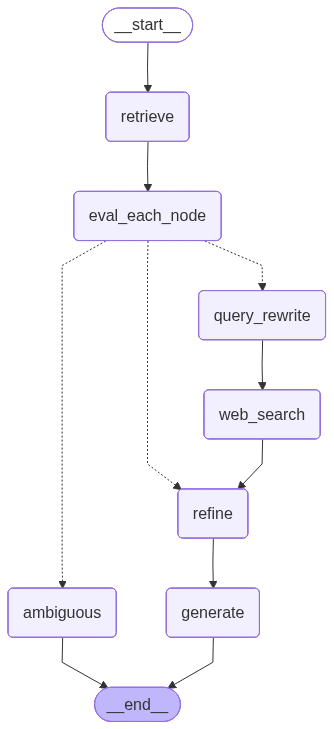

In [113]:
graph = StateGraph(RagState)
graph.add_node('retrieve',retrieve)
graph.add_node('refine',refine)
graph.add_node('generate',generate)
graph.add_node('eval_each_node',eval_each_node)
graph.add_node('ambiguous',ambiguous)
graph.add_node('web_search',web_search)
graph.add_node('query_rewrite',query_rewrite)

graph.add_edge(START,'retrieve')
graph.add_edge('retrieve','eval_each_node')
graph.add_conditional_edges('eval_each_node',conditional_edge,{'ambiguous':'ambiguous','query_rewrite':'query_rewrite','refine':'refine'})
graph.add_edge('query_rewrite','web_search')
graph.add_edge('web_search','refine')
graph.add_edge('refine','generate')
graph.add_edge('generate',END)
graph.add_edge('ambiguous',END)

chatbot = graph.compile()

chatbot

In [127]:
response = chatbot.invoke({'question':'ai news in 2026?'})

print(response)

Documents retrieved length of docs is :  4
Incorrect : 
Control is at query_rewrite :  AI news 2026
AI news 2026
Control is at web search :  ["TITLE : What's next in AI: 7 trends to watch in 2026 - Microsoft Source\n\nURL: https://news.microsoft.com/source/features/ai/whats-next-in-ai-7-trends-to-watch-in-2026/ \nCONTENT: by Susanna Ray \n\nAI is entering a new phase, one defined by real-world impact.\n\nAfter several years of experimentation, 2026 is shaping up to be the year AI evolves from instrument to partner, transforming how we work, create and solve problems. Across industries, AI is moving beyond answering questions to collaborating with people and amplifying their expertise.\n\nThis transformation is visible everywhere. In medicine, AI is helping close gaps in care. In software development, it’s learning not just code but the context behind it. In scientific research, it’s becoming a true lab assistant. In quantum computing, new hybrid approaches are heralding breakthroughs o

c:\Users\Jay Kanakia\AppData\Local\Programs\Python\Python311\Lib\site-packages\langchain_openai\chat_models\base.py:2181: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


Refined content generated :  - TITLE : What's next in AI: 7 trends to watch in 2026 - Microsoft Source URL: https://news.microsoft.com/source/features/ai/whats-next-in-ai-7-trends-to-watch-in-2026/ CONTENT: by Susanna Ray AI is entering a new phase, one defined by real-world impact.After several years of experimentation, 2026 is shaping up to be the year AI evolves from instrument to partner, transforming how we work, create and solve problems.Across industries, AI is moving beyond answering questions to collaborating with people and amplifying their expertise.In medicine, AI is helping close gaps in care.In quantum computing, new hybrid approaches are heralding breakthroughs once thought impossible.[...] As AI agents become digital colleagues and take on specific tasks at human direction, organizations are strengthening security to keep pace with new risks.These seven trends to watch in 2026 show what’s possible when people join forces with AI.Image 4 AI will amplify what people can a

In [128]:
print(response['answer'])
print('*'*100)
print(response['verdict'])
print('*'*100)
print(response['reason'])

In 2026, AI is expected to evolve from an instrument to a partner, transforming how people work, create, and solve problems across industries. AI will collaborate with humans to amplify their expertise, help close gaps in care in the medical field, generate hypotheses, guide scientific experiments, and work alongside human researchers in various fields like physics, chemistry, and biology. AI will also shift from individual usage to team and workflow orchestration, becoming an active collaborator capable of meaningful problem-solving and decision-making. Additionally, there will be a focus on efficiency and the emergence of multimodal AI models that can perceive and act more like humans.
****************************************************************************************************
INCORRECT
****************************************************************************************************
All doc score is less than 0.3


In [129]:
response['refined_content']

"- TITLE : What's next in AI: 7 trends to watch in 2026 - Microsoft Source URL: https://news.microsoft.com/source/features/ai/whats-next-in-ai-7-trends-to-watch-in-2026/ CONTENT: by Susanna Ray AI is entering a new phase, one defined by real-world impact.After several years of experimentation, 2026 is shaping up to be the year AI evolves from instrument to partner, transforming how we work, create and solve problems.Across industries, AI is moving beyond answering questions to collaborating with people and amplifying their expertise.In medicine, AI is helping close gaps in care.In quantum computing, new hybrid approaches are heralding breakthroughs once thought impossible.[...] As AI agents become digital colleagues and take on specific tasks at human direction, organizations are strengthening security to keep pace with new risks.These seven trends to watch in 2026 show what’s possible when people join forces with AI.Image 4 AI will amplify what people can achieve together Aparna Chenn

In [130]:
response['web_query']

'AI news 2026'

In [131]:
response['web_docs']

[Document(metadata={'url': 'https://news.microsoft.com/source/features/ai/whats-next-in-ai-7-trends-to-watch-in-2026/', 'title': "What's next in AI: 7 trends to watch in 2026 - Microsoft Source"}, page_content="TITLE : What's next in AI: 7 trends to watch in 2026 - Microsoft Source\n\nURL: https://news.microsoft.com/source/features/ai/whats-next-in-ai-7-trends-to-watch-in-2026/ \nCONTENT: by Susanna Ray \n\nAI is entering a new phase, one defined by real-world impact.\n\nAfter several years of experimentation, 2026 is shaping up to be the year AI evolves from instrument to partner, transforming how we work, create and solve problems. Across industries, AI is moving beyond answering questions to collaborating with people and amplifying their expertise.\n\nThis transformation is visible everywhere. In medicine, AI is helping close gaps in care. In software development, it’s learning not just code but the context behind it. In scientific research, it’s becoming a true lab assistant. In qu